# Project 09 -- Anthony Micco

**TA Help:** N/A

**Collaboration:** N/A

**Internet Resources:** 
- https://www.geeksforgeeks.org/machine-learning/k-nearest-neighbours/ (Used to help in KNN explanation)
- https://www.w3resource.com/machine-learning/scikit-learn/iris/python-machine-learning-k-nearest-neighbors-algorithm-exercise-8.php (Used example to assist in generating Training vs. Test Accuracy plot)
- https://scikit-learn.org/stable/modules/cross_validation.html#cross-validation (Documentation helped calculate mean accuracy and standard deviation)
- https://www.w3schools.com/python/python_string_formatting.asp (Used to help format metrics calculated from models)
  
**ChatGPT, Gemini, Claude, etc:** N/A

**Link to AI Chat History**: N/A

**OVERALL MESSAGE:** Any time that you used anything except your brain to solve the questions in these projects, you need to disclose such resources at the start of the project, with details about your usage of the tools.

**YOUR OWN WORK:** Even when you utilize other resources, do NOT just copy and paste.  Write all explanations in your own words, using several sentences in English, which are understandable and which you wrote (and did not just copy and paste).

## Question 1

In [2]:
#imports 
import pandas as pd
import numpy as np

In [3]:
#reading in the data
df = pd.read_csv("/anvil/projects/tdm/data/nhanes/Nhanes_cvd_raw.csv")

In [4]:
#printing the columns of the dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27493 entries, 0 to 27492
Data columns (total 47 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SEQN                 27493 non-null  int64  
 1   Protein              19086 non-null  float64
 2   Carbohydrates        19086 non-null  float64
 3   Sugars               19086 non-null  float64
 4   Fiber                19086 non-null  float64
 5   Saturated_Fat        19086 non-null  float64
 6   Monounsaturated_Fat  19086 non-null  float64
 7   Polyunsaturated_Fat  19086 non-null  float64
 8   Cholesterol          19086 non-null  float64
 9   Beta_Carotene        19086 non-null  float64
 10  Cryptoxanthin        19086 non-null  float64
 11  Lutein_Zeaxanthin    19086 non-null  float64
 12  Thiamin              19086 non-null  float64
 13  Riboflavin           19086 non-null  float64
 14  Niacin               19086 non-null  float64
 15  Vitamin_B6           19086 non-null 

In [5]:
#printing the head of the dataframe
df.head()

,SEQN,Protein,Carbohydrates,Sugars,Fiber,Saturated_Fat,Monounsaturated_Fat,Polyunsaturated_Fat,Cholesterol,Beta_Carotene,...,Heart_attack,Stroke,Angina,Age,BMI,Waist_circ,Systolic_BP,Diastolic_BP,Total_Colesterol,C_Reactive
0,109263,52.79,187.65,73.42,9.4,18.660,15.420,9.510,71.0,405.0,...,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN
1,109264,55.55,121.68,27.86,8.2,7.861,13.896,12.426,153.0,3285.0,...,NaN,NaN,NaN,13,17.6,63.8,109.0,67.0,166.0,0.11
2,109265,57.47,246.53,157.08,7.6,33.562,28.231,12.957,123.0,1293.0,...,NaN,NaN,NaN,2,15.0,41.2,NaN,NaN,NaN,0.31
3,109266,52.58,217.69,94.20,20.7,22.175,25.513,19.171,120.0,461.0,...,2.0,2.0,2.0,29,37.8,117.9,99.0,56.0,195.0,0.72
4,109269,24.96,159.99,84.83,5.1,15.273,16.084,22.317,61.0,174.0,...,NaN,NaN,NaN,2,NaN,NaN,NaN,NaN,NaN,0.73


In [6]:
#printing the shape of the dataframe
df.shape

(27493, 47)

In [7]:
#finding the number of null values in each column
df.isna().sum()

SEQN                       0
Protein                 8407
Carbohydrates           8407
Sugars                  8407
Fiber                   8407
Saturated_Fat           8407
Monounsaturated_Fat     8407
Polyunsaturated_Fat     8407
Cholesterol             8407
Beta_Carotene           8407
Cryptoxanthin           8407
Lutein_Zeaxanthin       8407
Thiamin                 8407
Riboflavin              8407
Niacin                  8407
Vitamin_B6              8407
Folic_Acid              8407
Food_Folate             8407
Iron                    8407
Choline                 8407
Vitamin_B12             8407
Vitamin_C               8407
Vitamin_D               8407
Vitamin_E               8407
Vitamin_K               8407
Calcium                 8407
Phosphorus              8407
Magnesium               8407
Zinc                    8407
Copper                  8407
Sodium                  8407
Potassium               8407
Selenium                8407
Theobromine             8407
Moisture      

In [8]:
#defining the subset of relevant features
features = ['Age', 'BMI', 'Systolic_BP', 'Diastolic_BP', 'Total_Colesterol', 'C_Reactive', 'Sodium', 'Saturated_Fat']

In [9]:
#checking to see counts of values in HeartAttack, Stroke, Angine, Coronary columns
for col in ["Heart_attack","Stroke","Angina","Coronary"]:
    print(col)
    print(df[col].value_counts())
    print()

Heart_attack
Heart_attack
2.0    16553
1.0      421
9.0       66
Name: count, dtype: int64

Stroke
Stroke
2.0    16147
1.0      854
9.0       37
Name: count, dtype: int64

Angina
Angina
2.0    16248
1.0      764
9.0       27
Name: count, dtype: int64

Coronary
Coronary
2.0    16152
1.0      825
9.0       62
Name: count, dtype: int64



In [10]:
#removing Refused and Don't Know values from HeartAttack column
df = df[df["Heart_attack"].isin([1,2])]

In [11]:
#recoding the column to be 0's (No) or 1's (Yes)
df["Heart_attack"] = df["Heart_attack"].map({1:1,2:0})

In [12]:
#filtering all unnecessary columns for our analysis and dropping null values
clean_df = df[features + ["Heart_attack"]].dropna()

In [13]:
#printing the head and shape of the new dataframe
clean_df.head()

,Age,BMI,Systolic_BP,Diastolic_BP,Total_Colesterol,C_Reactive,Sodium,Saturated_Fat,Heart_attack
3,29,37.8,99.0,56.0,195.0,0.72,2001.0,22.175,0
6,49,29.7,102.0,65.0,147.0,28.68,5446.0,39.178,0
8,36,21.9,116.0,68.0,164.0,0.98,1990.0,2.698,0
9,68,30.2,138.0,70.0,105.0,1.60,6717.0,21.800,0
17,76,26.6,141.0,77.0,233.0,3.11,2456.0,29.435,0


In [14]:
clean_df.shape

(10892, 9)

1a) There are 27493 rows and 47 columns in the original dataset. One thing I notice is that many of the columns have missing or null values, so those will need to be cleaned. I also notice that all of the data is numerical and either a float or integer, so there are no categorical columns based on the df.info() function. \
1d) The new, cleaned data frame now contains 9 columns and 10892 rows. 

## Question 2

In [15]:
#imports
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

In [16]:
#splitting our data in features and target
X = clean_df[features]
y = clean_df["Heart_attack"]

In [17]:
#scaling the data and generating a train/test split
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#creating an 80/20 train/test split with random_state for reproducability
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42) 

In [18]:
#initializing the fitting a KNN model using scikit-learn's neighbors module
knn = KNeighborsClassifier(n_neighbors=5) # Using 5 nearest neighbors
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [19]:
#getting model's predictions
train_predict = knn.predict(X_train)
train_accuracy = accuracy_score(y_train, train_predict)
test_predict = knn.predict(X_test)
test_accuracy = accuracy_score(y_test, test_predict)

In [20]:
print(f"Training Accuracy: {train_accuracy}\nTest Accuracy:     {test_accuracy}")

Training Accuracy: 0.9744060599104786
Test Accuracy:     0.9821018815970629


2b) KNN works by calculating the distance between points and then classifying them by based on how close they are to each of the K=n neighbors. In our case, the model calculates the distance from each point and uses the 5 nearest neighbors to determine the classification. The model classifies the new instance based on the majority class of its 5 nearest neighbors. For example, if three instances of class A are closer to our new instance and class B only has two instances closer to our new instance, the model will classify the new instance as class A since there are more neighbors closer to it from class A. The model repeats this for every data point until every data point has been classified. This then creates clusters of data points that represent each class in the dataset. \
2c) The train and test accuracies signify how many predictions the model accurately classified in comparison to the total number of samples. So for the training data, the model had a 97.4% accuracy when classifying the data using the training data, while the testing data produced a 98.2% accuracy when classifying the data using the test data. This indicates that the model was quite accurate when predicting if a person had a heart attack using the features we provided.  

## Question 3

In [21]:
#training a model on different values of k
# Store accuracy scores
train_acc = []
test_acc = []

k_vals = [1, 3, 5, 10, 20, 50]

for k in k_vals:
    # Initialize KNN model with current k value
    knn = KNeighborsClassifier(n_neighbors=k)

    knn.fit(X_train, y_train)

    # Predictions on data model has seen
    train_predict = knn.predict(X_train)
    # Prediction on unseen data
    test_predict = knn.predict(X_test)

    # Calculate the train and test accuracies and add to train_acc and test_acc
    train_accuracy = accuracy_score(y_train, train_predict)
    test_accuracy = accuracy_score(y_test, test_predict)

    train_acc.append(train_accuracy)
    test_acc.append(test_accuracy)

In [25]:
#imports
import matplotlib.pyplot as plt

Text(0.5, 1.0, 'Train, Test Accuracies')

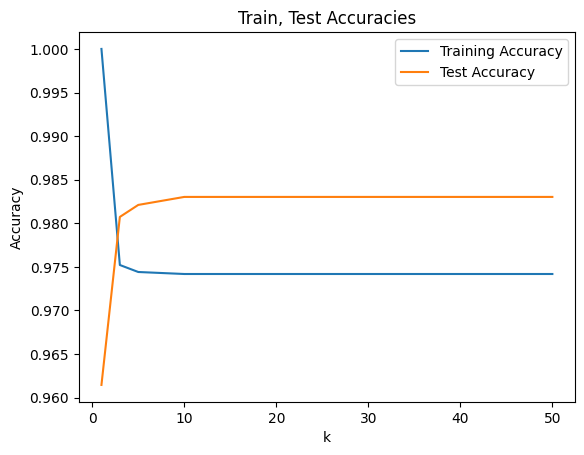

In [33]:
#plotting training vs. testing accuracy scores
plt.plot(k_vals, train_acc, label ="Training Accuracy")
plt.plot(k_vals, test_acc, label="Test Accuracy")
plt.legend()
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("Train, Test Accuracies")

In [34]:
#training the same model on the same dataset multiple times
scores = []

for i in range(20):
    X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2)
    model = KNeighborsClassifier(n_neighbors=10)
    model.fit(X_train, y_train)
    predict = model.predict(X_test)
    scores.append(accuracy_score(y_test, predict))

print(scores)

[0.9761358421294172, 0.9747590637907297, 0.9743001376778339, 0.9729233593391464, 0.9738412115649381, 0.9784304726938963, 0.9729233593391464, 0.9715465810004589, 0.976594768242313, 0.9807251032583754, 0.9761358421294172, 0.9779715465810005, 0.9779715465810005, 0.9747590637907297, 0.976594768242313, 0.9761358421294172, 0.9733822854520422, 0.9775126204681046, 0.9706287287746673, 0.9724644332262505]


3c) One thing I notice from the plot is that at k=1, the training accuracy is at a maximum, while the test accuracy is at a minimum. However, this does not last long, as the training accuracy decreases as k increase, while the test accuracy increase while k increases until about k=10, then both accuracies begin to plateau and not change very much at all. I also notice that it appears the two accuracies are equal at approximately k=5 before they diverge and increase and decrease before plateauing at k=10. 
3d) The issues this causes is in relation to our k value. If we pick a k value that is too high, the model will begin underfitting the data because it's too general, plateauing and not improving, but if the value is too low, then the model might overfit the data because it does not learn enough patterns to accurately apply them to new data. We can also have problems if we get a testing or training split that has a distribution not representative of the entire dataset so our training and test accuracies may be impacted by that split.  

## Question 4

In [35]:
#imports
from sklearn.model_selection import cross_val_score, KFold

In [36]:
#creating a KNN classifier with K-fold cross validation
model = KNeighborsClassifier(n_neighbors=10) #model with 10 neighbors

#10 fold cross-validation
kf = KFold(n_splits=10, shuffle=True, random_state=42)
cv_scores=cross_val_score(model,X_scaled,y,cv=kf)

In [42]:
#printing the cross validation scores, mean accuracy, and standard deviation
print(f"Cross Validation Scores: {cv_scores}\nMean Accuracy: {cv_scores.mean():.4f}\nStandard Deviation: {cv_scores.std():.4f}")

Cross Validation Scores: [0.98348624 0.98165138 0.97428834 0.97979798 0.97979798 0.97337006
 0.97796143 0.97520661 0.96602388 0.96786042]
Mean Accuracy: 0.9759
Standard Deviation: 0.0054


4b) The n_splits indicates the total number of partitions the function will split our data into. In our case, the 10 was split into 10 different subsets of data, while the shuffle parameter ensures that the rows are randomized so there is a uniqueness to our data and it is not split based on the order of the data in the dataset. \
4c) The mean accuracy of the data signifies the model's average accuracy when using each fold's split as input, so the model had a 97.6% accuracy on average across all the splits. The standard deviation signifies how far off on average each accuracy was from the mean average, so each of the model's averages were pretty close to each other and did not vary often. \
4d) One advantage of k-fold cross validation is that the model is trained on all the data since each fold only takes out one partition for test data each time. This can help improve the accuracy of the model since it is being exposed to more data. Additionally, it can help eliminate bias in a model since by setting the parameter shuffle=True, it randomizes the order in which the data is partitioned in each fold. One disadvantage of k-fold cross validation is it takes longer to run than a typical model since it is technically training k models each time instead of a single model. 

## Question 5

In [43]:
#imports 
from sklearn.model_selection import LeaveOneOut

In [46]:
#printing the number of rows in our dataset
print("Number of rows in dataset:", clean_df.shape[0])

Number of rows in dataset: 10892


In [47]:
#applying LOOCV to our model 
model = KNeighborsClassifier(n_neighbors=10)

#Initializing Leave one out cross validation
loo = LeaveOneOut()

#compute cross validation scores
loo = cross_val_score(model, X_scaled, y, cv=loo)

In [53]:
#printing the total number of folds and mean accuracy
print(f"Number of folds: {len(loo)}" )
print(f"Mean Accuracy: {loo.mean():.4f}") 

Number of folds: 10892
Mean Accuracy: 0.9759


5b) LOOCV works by iterating through each row of the data and only using a single row as validation data and using the rest as training data. This repeats until each row in the dataset has been used as a validation row, so the k-folds for this method is k=n folds where n is the number of rows in the dataset. This is different from the original method because we specify how many folds we want and then the data is partitioned into that many folds with only one of the k folds being used as validation, but as long as k is greater than the number of rows, then the validation data for each fold won't be a single row. \
5c) Much like the original method, one of the advantages of LOOCV is that the model sees all of the data, so it could help improve the model's accuracy. It is also very effective on smaller datasets because it can easily pickup on patterns relatively quickly since the training sets are much larger than a typical train/test split. Since the training sets are so much larger, the model produces very little bias since the training data is almost identical to the full dataset since the training data has a size of n-1. However, LOOCV is very slow to run since it trains a model on every row of a dataset, so it is not ideal to use on larger datasets. It also produces high variance because the training sets of each iteration are almost identical minus a single row, each training set is highly correlated so the predictions can vary if the data is modified. 

## Pledge

By submitting this work I hereby pledge that this is my own, personal work. I've acknowledged in the designated place at the top of this file all sources that I used to complete said work, including but not limited to: online resources, books, and electronic communications. I've noted all collaboration with fellow students and/or TA's. I did not copy or plagiarize another's work.

> As a Boilermaker pursuing academic excellence, I pledge to be honest and true in all that I do. Accountable together – We are Purdue.

https://www.purdue.edu/odos/osrr/honor-pledge/
